# EDA and Training Notebook

**Current stage:** Data preparation + Exploratory Data Analysis only.

- Dataset: UCI Algerian Forest Fires (ID 547)
- Task: Fire vs Not Fire (binary classification)
- This notebook does **not** train Random Forest yet.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure project root is on the path when running from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FEATURE_COLUMNS, NUMERIC_FEATURES, PROCESSED_DATA_PATH, TARGET_COLUMN
from src.preprocessing import build_preprocessor, select_features

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DATA_PATH)


Project root: /workspace
Processed data: /workspace/data/processed/algerian_forest_fires_cleaned.csv


## 1. Load cleaned processed dataset

The cleaned file is produced by `python -m src.prepare_data` and must not be confused with `data/raw/`.


In [2]:
df = pd.read_csv(PROCESSED_DATA_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Shape: (243, 12)
Columns: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'Region', 'month', 'Classes', 'Classes_encoded']


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,Region,month,Classes,Classes_encoded
0,29,57,18,0.0,65.7,3.4,7.6,1.3,Bejaia,6,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,Bejaia,6,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,Bejaia,6,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,Bejaia,6,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,Bejaia,6,not fire,0


## 2. Basic checks

In [3]:
print("Dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nClass counts:\n", df[TARGET_COLUMN].value_counts())
print("\nEncoded class counts:\n", df["Classes_encoded"].value_counts().sort_index())
print("\nRegion counts:\n", df["Region"].value_counts())
print("\nMonth counts:\n", df["month"].value_counts().sort_index())


Dtypes:
 Temperature          int64
RH                   int64
Ws                   int64
Rain               float64
FFMC               float64
DMC                float64
DC                 float64
ISI                float64
Region                 str
month                int64
Classes                str
Classes_encoded      int64
dtype: object

Missing values:
 Temperature        0
RH                 0
Ws                 0
Rain               0
FFMC               0
DMC                0
DC                 0
ISI                0
Region             0
month              0
Classes            0
Classes_encoded    0
dtype: int64

Class counts:
 Classes
fire        137
not fire    106
Name: count, dtype: int64

Encoded class counts:
 Classes_encoded
0    106
1    137
Name: count, dtype: int64

Region counts:
 Region
Bejaia            122
Sidi-Bel-Abbes    121
Name: count, dtype: int64

Month counts:
 month
6    60
7    61
8    62
9    60
Name: count, dtype: int64


## 3. Class distribution

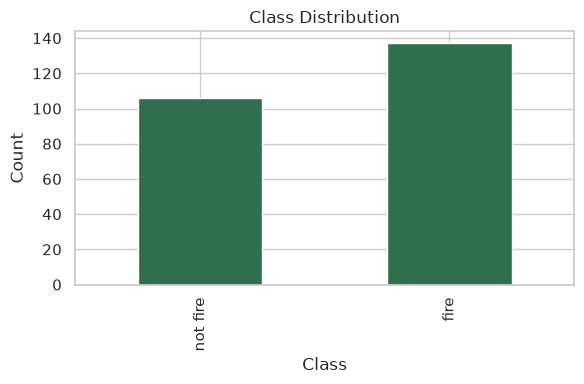

In [4]:
ax = df[TARGET_COLUMN].value_counts().reindex(["not fire", "fire"]).plot(
    kind="bar", color="#2f6f4e", figsize=(6, 4), title="Class Distribution"
)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 4. Numeric feature distributions

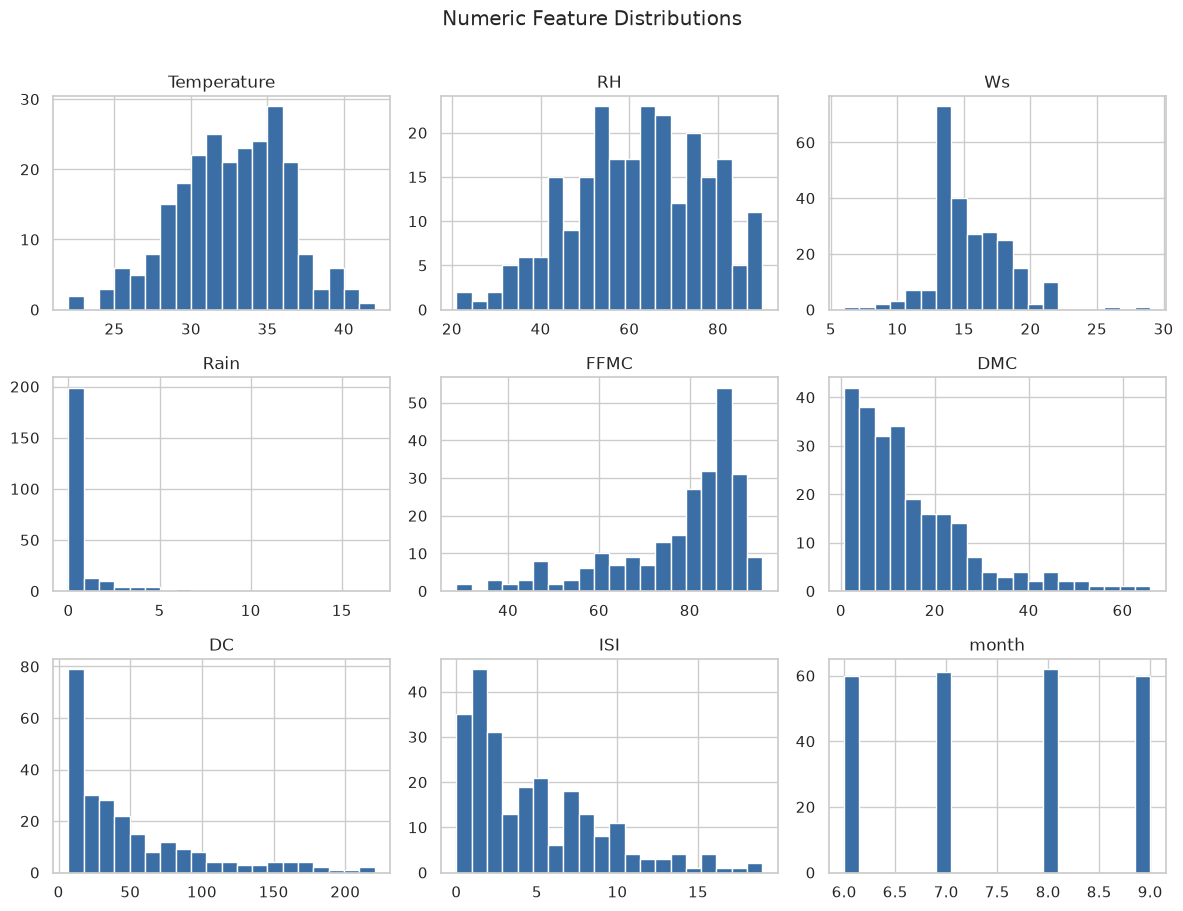

In [5]:
df[NUMERIC_FEATURES].hist(figsize=(12, 9), bins=20, color="#3b6ea5", edgecolor="white")
plt.suptitle("Numeric Feature Distributions", y=1.01)
plt.tight_layout()
plt.show()


## 5. Correlation heatmap

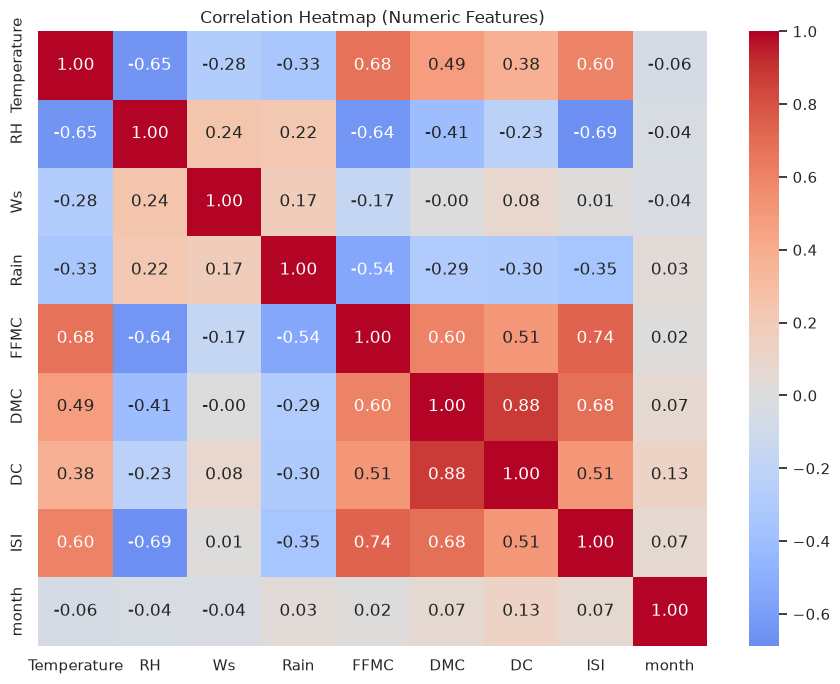

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,month
Temperature,1.000,-0.651,-0.285,-0.326,0.677,0.486,0.376,0.604,-0.057
RH,-0.651,1.000,0.244,0.222,-0.645,-0.409,-0.227,-0.687,-0.041
Ws,-0.285,0.244,1.000,0.172,-0.167,-0.001,0.079,0.009,-0.040
Rain,-0.326,0.222,0.172,1.000,-0.544,-0.289,-0.298,-0.347,0.035
FFMC,0.677,-0.645,-0.167,-0.544,1.000,0.604,0.507,0.740,0.017
DMC,0.486,-0.409,-0.001,-0.289,0.604,1.000,0.876,0.680,0.068
DC,0.376,-0.227,0.079,-0.298,0.507,0.876,1.000,0.509,0.127
ISI,0.604,-0.687,0.009,-0.347,0.740,0.680,0.509,1.000,0.066
month,-0.057,-0.041,-0.040,0.035,0.017,0.068,0.127,0.066,1.000


In [6]:
corr = df[NUMERIC_FEATURES].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()
corr.round(3)


## 6. Features by Fire vs Not Fire

In [7]:
summary = df.groupby(TARGET_COLUMN)[NUMERIC_FEATURES].agg(["mean", "median"]).round(2)
summary


Temperature            RH            Ws         Rain          FFMC  \
                mean median   mean median   mean median  mean median   mean   
Classes                                                                       
fire           33.80   34.0  56.42   56.0  15.32   15.0  0.10    0.0  87.54   
not fire       30.03   30.0  69.31   71.0  15.72   15.0  1.62    0.6  65.32   

                   DMC            DC          ISI        month         
         median   mean median   mean median  mean median  mean median  
Classes                                                                
fire      87.80  21.05  18.00  70.82  54.20  7.42    6.8  7.53    8.0  
not fire  68.25   6.45   4.75  21.79   9.65  1.28    1.2  7.47    7.0

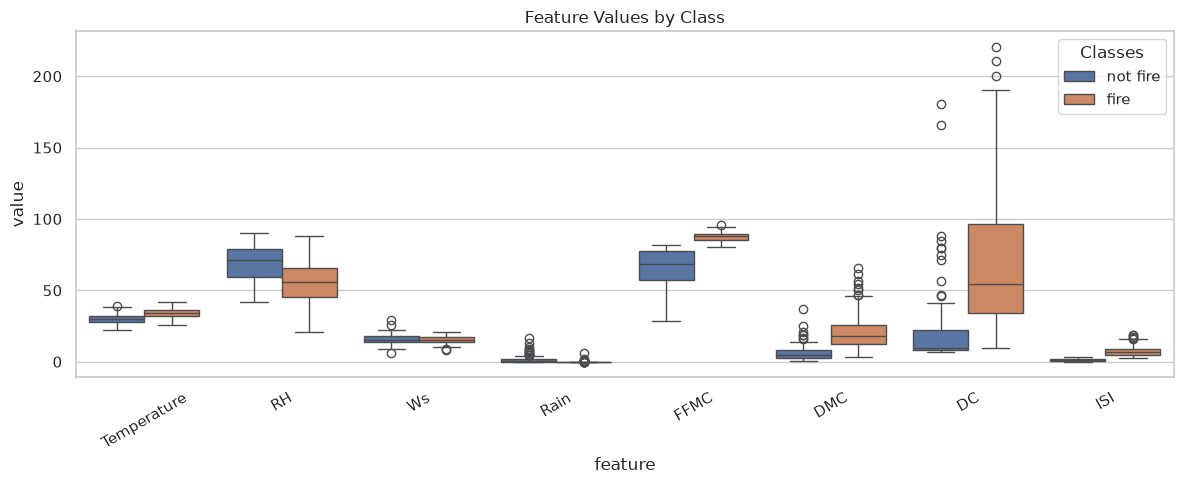

In [8]:
plot_cols = [c for c in NUMERIC_FEATURES if c != "month"]
melted = df.melt(id_vars=[TARGET_COLUMN], value_vars=plot_cols, var_name="feature", value_name="value")
plt.figure(figsize=(12, 5))
sns.boxplot(data=melted, x="feature", y="value", hue=TARGET_COLUMN)
plt.title("Feature Values by Class")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 7. Region and month vs class

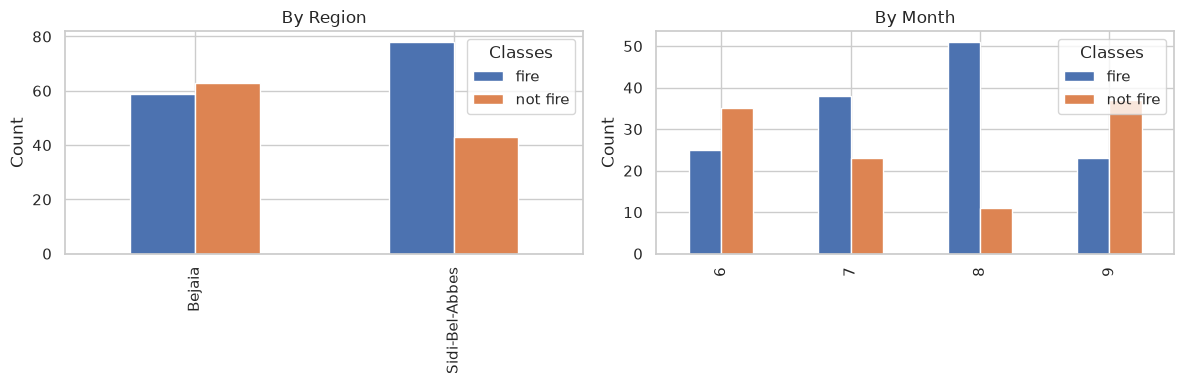

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.crosstab(df["Region"], df[TARGET_COLUMN]).plot(kind="bar", ax=axes[0], title="By Region")
pd.crosstab(df["month"], df[TARGET_COLUMN]).plot(kind="bar", ax=axes[1], title="By Month")
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 8. Preprocessing pipeline smoke test (no training)

Fit the shared sklearn preprocessor on all cleaned features to confirm it works.
**No Random Forest is trained here.**


In [10]:
X = select_features(df)
preprocessor = build_preprocessor()
X_transformed = preprocessor.fit_transform(X)
print("Input feature columns:", list(X.columns))
print("Transformed shape:", X_transformed.shape)
print("Transformed feature names:", list(preprocessor.get_feature_names_out()))


Input feature columns: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'Region', 'month']
Transformed shape: (243, 11)
Transformed feature names: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'month', 'Region_Bejaia', 'Region_Sidi-Bel-Abbes']


## Next step (not done yet)

After approval, the next phase will train a Random Forest classifier using the same preprocessing object for train and inference.
